# Bài 3: Data crawling

In [13]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

## 3.1. Thu thập dữ liệu

### 3.1.1. Viết code cào dữ liệu từ trang web trên, lưu kết quả vào 1 file tương ứng (kq.txt) và mô tả ngắn gọn về cấu trúc của trang Web

In [14]:
url = "http://quotes.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')

with open('kq.txt', 'w', encoding='utf-8') as f:
    f.write(str(soup))


### Mô tả ngắn gọn về cấu trúc trang web:


### 3.1.2. Với dữ liệu bạn vừa cào về, bạn hãy thực hiện các yêu cầu sau:

#### a. Đọc  tất  cả  các  thẻ  html  (div)  với  lớp  là  "quote"  và lưu nó trong biến 'result’, hiển thị giá trị biến 'result’ ra màn hình

In [20]:
soup = BeautifulSoup(response.content, 'html.parser')

result = soup.find_all('div', class_='quote')
print(result)

[<div class="quote" itemscope="" itemtype="http://schema.org/CreativeWork">
<span class="text" itemprop="text">“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”</span>
<span>by <small class="author" itemprop="author">Albert Einstein</small>
<a href="/author/Albert-Einstein">(about)</a>
</span>
<div class="tags">
            Tags:
            <meta class="keywords" content="change,deep-thoughts,thinking,world" itemprop="keywords"/>
<a class="tag" href="/tag/change/page/1/">change</a>
<a class="tag" href="/tag/deep-thoughts/page/1/">deep-thoughts</a>
<a class="tag" href="/tag/thinking/page/1/">thinking</a>
<a class="tag" href="/tag/world/page/1/">world</a>
</div>
</div>, <div class="quote" itemscope="" itemtype="http://schema.org/CreativeWork">
<span class="text" itemprop="text">“It is our choices, Harry, that show what we truly are, far more than our abilities.”</span>
<span>by <small class="author" itemprop="author">J.K.

#### b. Tìm  trong  biến  'result’  vừa  rồi  các  dữ  liệu  có  chứa  nhãn  "small"    với class là "author" và in kết quả ra màn hình

In [21]:
for quote in result:
    author_tag = quote.find('small', class_='author')
    if author_tag:
        print(author_tag.text)


Albert Einstein
J.K. Rowling
Albert Einstein
Jane Austen
Marilyn Monroe
Albert Einstein
André Gide
Thomas A. Edison
Eleanor Roosevelt
Steve Martin


#### c.  Viết hàm tacgiaLink() để lấy nội dung của mỗi tác giả. Với mỗi tác giả in ra màn hình các nội dung:
- Tên tác giả
- Đường link của tác giả
- Ngày tháng năm sinh
- Và câu nói nổi tiếng của tác giả


In [22]:
def tacgiaLink():
    for r in result:
        author = r.find('small', class_='author')
        if author:
            author_link = url + r.find('a')['href']
            response_author = requests.get(author_link)
            soup_author = BeautifulSoup(response_author.content, 'html.parser')
            born_date = soup_author.find('span', class_='author-born-date').text
            print("Tên tác giả: ",author.text)
            print("Đường link tác giả: ",author_link)
            print(f'Ngày tháng năm sinh : {born_date}')
            print(f'Câu nói nổi tiếng: {r.find("span", class_="text").text.strip()}')


tacgiaLink()

Tên tác giả:  Albert Einstein
Đường link tác giả:  http://quotes.toscrape.com//author/Albert-Einstein
Ngày tháng năm sinh : March 14, 1879
Câu nói nổi tiếng: “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
Tên tác giả:  J.K. Rowling
Đường link tác giả:  http://quotes.toscrape.com//author/J-K-Rowling
Ngày tháng năm sinh : July 31, 1965
Câu nói nổi tiếng: “It is our choices, Harry, that show what we truly are, far more than our abilities.”
Tên tác giả:  Albert Einstein
Đường link tác giả:  http://quotes.toscrape.com//author/Albert-Einstein
Ngày tháng năm sinh : March 14, 1879
Câu nói nổi tiếng: “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
Tên tác giả:  Jane Austen
Đường link tác giả:  http://quotes.toscrape.com//author/Jane-Austen
Ngày tháng năm sinh : December 16, 1775
Câu nói nổi tiếng: “The person, be it gentleman or lady, who has n

#### d. Lưu kết quả ở câu c vào file Quote.csv tương ứng, với mỗi tác giả là 1 dòng dữ liệu. Bạn được yêu cầu thu thập ít nhất 40 câu nói nổi tiếng từ trang web trên một cách tự động theo code của các ý trên?

In [23]:
import csv
page = 1
if page == 1:
    with open('Quote.csv', mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        # Ghi tiêu đề cho các cột
        writer.writerow(['Tacgia', 'Link', 'Born Date', 'Famous Quote',])
while True:
    url = 'http://quotes.toscrape.com/page/{}'.format(page)
    r = requests.get(url)
    soup = BeautifulSoup(r.text,'html.parser')
    quotes = soup.find_all('div', class_='quote')
    with open('Quote.csv', mode='a', newline='', encoding='utf-8') as file:
    # Tạo đối tượng writer
        writer = csv.writer(file)
        # Lấy thông tin tác giả và ghi vào file CSV
        for quote in quotes:
            author = quote.find('small', class_='author')
            if author:
                url = 'http://quotes.toscrape.com/'
                author_link = url + quote.find('a')['href']
                response_author = requests.get(author_link)
                soup_author = BeautifulSoup(response_author.content, 'html.parser')

                born_date = soup_author.find('span', class_='author-born-date')
                if born_date:
                    born_date = born_date.text
                else:
                    born_date = "Unknown"
                famous_quote = quote.find('span', class_='text').text.strip()
                # Ghi dữ liệu vào các dòng
                writer.writerow([author.text, author_link,born_date, famous_quote])
    if soup.find('li',attrs={"class":"next"}) is None:
        break
    page +=1


## 3.2. Khai phá dữ liệu

### 3.2.1. Xử lý dữ liệu- Data Imputation

#### Thêm vào Trường STT và điền tự động dữ liệu của trường

In [81]:
# Đọc file CSV vào DataFrame
df = pd.read_csv('Quote.csv')
df.columns = ['Tacgia', 'Link', 'NamSinh','Quote']

In [82]:
df.index.name = 'STT'
df

,Tacgia,Link,NamSinh,Quote
STT,,,,
0,Albert Einstein,http://quotes.toscrape.com//author/Albert-Eins...,"March 14, 1879",“The world as we have created it is a process ...
1,J.K. Rowling,http://quotes.toscrape.com//author/J-K-Rowling,"July 31, 1965","“It is our choices, Harry, that show what we t..."
2,Albert Einstein,http://quotes.toscrape.com//author/Albert-Eins...,"March 14, 1879",“There are only two ways to live your life. On...
3,Jane Austen,http://quotes.toscrape.com//author/Jane-Austen,"December 16, 1775","“The person, be it gentleman or lady, who has ..."
4,Marilyn Monroe,http://quotes.toscrape.com//author/Marilyn-Monroe,"June 01, 1926","“Imperfection is beauty, madness is genius and..."
...,...,...,...,...
95,Harper Lee,http://quotes.toscrape.com//author/Harper-Lee,"April 28, 1926",“You never really understand a person until yo...
96,Madeleine L'Engle,http://quotes.toscrape.com//author/Madeleine-L...,"November 29, 1918",“You have to write the book that wants to be w...
97,Mark Twain,http://quotes.toscrape.com//author/Mark-Twain,"November 30, 1835",“Never tell the truth to people who are not wo...


#### Xử lý giá của dữ liệu Trường ngày sinh
    Xem file csv chúng em thấy dữ liệu trường ngày sinh không bị thiếu, nhưng nếu đề xuất cách điền thì chúng em có thể lên mạng tìm thông tin và điền vào các dòng thiếu dữ liệu.    

In [83]:
df_null = df.copy()
df_null.isnull().sum()

Tacgia     0
Link       0
NamSinh    0
Quote      0
dtype: int64

#### Thêm vào Trường Tuoi (Tuổi) và đề xuất cách điền tuổi của các tác giả


In [84]:
Tuoilist = [76, 55, 41, 36, 81, 84, 78, 75, 36, 87, 49,
            87, 56, 74, 86, 69, 78, 87, 78, 53, 78, 85,
            87, 61, 72, 64, 39, 63, 72, 71, 47, 61, 87,
            94, 73, 58, 81, 83, 66, 91, 71, 40, 66, 77,
            27, 77, 68, 56, 89, 88]

Tuoidict = {}
for i, j in zip(df.Tacgia.unique().tolist(), Tuoilist):
        Tuoidict[i] = j
Tuoidict

{'Albert Einstein': 76,
 'J.K. Rowling': 55,
 'Jane Austen': 41,
 'Marilyn Monroe': 36,
 'André Gide': 81,
 'Thomas A. Edison': 84,
 'Eleanor Roosevelt': 78,
 'Steve Martin': 75,
 'Bob Marley': 36,
 'Dr. Seuss': 87,
 'Douglas Adams': 49,
 'Elie Wiesel': 87,
 'Friedrich Nietzsche': 56,
 'Mark Twain': 74,
 'Allen Saunders': 86,
 'Pablo Neruda': 69,
 'Ralph Waldo Emerson': 78,
 'Mother Teresa': 87,
 'Garrison Keillor': 78,
 'Jim Henson': 53,
 'Charles M. Schulz': 78,
 'William Nicholson': 85,
 'Jorge Luis Borges': 87,
 'George Eliot': 61,
 'George R.R. Martin': 72,
 'C.S. Lewis': 64,
 'Martin Luther King Jr.': 39,
 'James Baldwin': 63,
 'Haruki Murakami': 72,
 'Alexandre Dumas fils': 71,
 'Stephenie Meyer': 47,
 'Ernest Hemingway': 61,
 'Helen Keller': 87,
 'George Bernard Shaw': 94,
 'Charles Bukowski': 73,
 'Suzanne Collins': 58,
 'J.R.R. Tolkien': 81,
 'Alfred Tennyson': 83,
 'Terry Pratchett': 66,
 'J.D. Salinger': 91,
 'George Carlin': 71,
 'John Lennon': 40,
 'W.C. Fields': 66,
 'Ay

In [85]:
df['Tuoi'] = df['Tacgia'].map(Tuoidict)
df.head()

,Tacgia,Link,NamSinh,Quote,Tuoi
STT,,,,,
0,Albert Einstein,http://quotes.toscrape.com//author/Albert-Eins...,"March 14, 1879",“The world as we have created it is a process ...,76
1,J.K. Rowling,http://quotes.toscrape.com//author/J-K-Rowling,"July 31, 1965","“It is our choices, Harry, that show what we t...",55
2,Albert Einstein,http://quotes.toscrape.com//author/Albert-Eins...,"March 14, 1879",“There are only two ways to live your life. On...,76
3,Jane Austen,http://quotes.toscrape.com//author/Jane-Austen,"December 16, 1775","“The person, be it gentleman or lady, who has ...",41
4,Marilyn Monroe,http://quotes.toscrape.com//author/Marilyn-Monroe,"June 01, 1926","“Imperfection is beauty, madness is genius and...",36


### 3.2.2. Khám phá dữ liệu- Data Exploration

In [89]:
print(f'Kích cỡ của dữ liệu: {df.shape}')

Kích cỡ của dữ liệu: (100, 5)


In [90]:
# Chuyển đổi cột 'NamSinh' sang định dạng datetime
df['NamSinh'] = pd.to_datetime(df['NamSinh'])

In [91]:
df.head()

,Tacgia,Link,NamSinh,Quote,Tuoi
STT,,,,,
0,Albert Einstein,http://quotes.toscrape.com//author/Albert-Eins...,1879-03-14,“The world as we have created it is a process ...,76
1,J.K. Rowling,http://quotes.toscrape.com//author/J-K-Rowling,1965-07-31,"“It is our choices, Harry, that show what we t...",55
2,Albert Einstein,http://quotes.toscrape.com//author/Albert-Eins...,1879-03-14,“There are only two ways to live your life. On...,76
3,Jane Austen,http://quotes.toscrape.com//author/Jane-Austen,1775-12-16,"“The person, be it gentleman or lady, who has ...",41
4,Marilyn Monroe,http://quotes.toscrape.com//author/Marilyn-Monroe,1926-06-01,"“Imperfection is beauty, madness is genius and...",36


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Tacgia   100 non-null    object        
 1   Link     100 non-null    object        
 2   NamSinh  100 non-null    datetime64[ns]
 3   Quote    100 non-null    object        
 4   Tuoi     100 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 4.0+ KB


#### Thống kê về tác giả và câu nói nổi tiếng có trong bộ dữ liệu

In [93]:
# Tính số lượng câu nói của mỗi tác giả
author_counts = df['Tacgia'].value_counts()

# Hiển thị 10 tác giả có nhiều câu nói nhất
print('Top 10 tác giả có nhiều câu nói nhất:')
print(author_counts.head(10))

Top 10 tác giả có nhiều câu nói nhất:
Tacgia
Albert Einstein      10
J.K. Rowling          9
Marilyn Monroe        7
Dr. Seuss             6
Mark Twain            6
C.S. Lewis            5
Jane Austen           5
Bob Marley            3
Eleanor Roosevelt     2
Charles Bukowski      2
Name: count, dtype: int64


In [94]:
# Tính số lượng xuất hiện câu nói của mỗi tác giả
quote_counts = df['Quote'].value_counts()

# Hiển thị 10 câu nói nổi tiếng có nhiều lần được trích dẫn nhất
print('Top 10 câu nói nổi tiếng có nhiều lần được trích dẫn nhất:')
print(quote_counts.head(10))

Top 10 câu nói nổi tiếng có nhiều lần được trích dẫn nhất:
Quote
“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”                                                                                                                                                                                                                                                                                                                                                                                                                     1
“To love at all is to be vulnerable. Love anything and your heart will be wrung and possibly broken. If you want to make sure of keeping it intact you must give it to no one, not even an animal. Wrap it carefully round with hobbies and little luxuries; avoid all entanglements. Lock it up safe in the casket or coffin of your selfishness. But in that casket, safe, dark, motionless, airless, it will change. It wi

#### Thống kê về năm sinh và độ tuổi của các tác giả.

In [95]:
#Thống kê về năm sinh và độ tuổi của các tác giả
df.groupby('Tacgia').first()[['NamSinh','Tuoi']].sort_values(by='Tuoi', ascending = True)

,NamSinh,Tuoi
Tacgia,,
Jimi Hendrix,1942-11-27,27
Bob Marley,1945-02-06,36
Marilyn Monroe,1926-06-01,36
Martin Luther King Jr.,1929-01-15,39
John Lennon,1940-10-09,40
Jane Austen,1775-12-16,41
Stephenie Meyer,1973-12-24,47
Douglas Adams,1952-03-11,49
Jim Henson,1936-09-24,53


In [96]:
# Thống kê về độ tuổi của các tác giả
print('Thống kê về độ tuổi của các tác giả:')
print(df['Tuoi'].describe())

Thống kê về độ tuổi của các tác giả:
count    100.000000
mean      66.020000
std       17.211683
min       27.000000
25%       55.000000
50%       72.000000
75%       78.000000
max       94.000000
Name: Tuoi, dtype: float64


In [98]:
# Thống kê về năm sinh của các tác giả
print('Thống kê về năm sinh của các tác giả:')
print(df['NamSinh'].describe())

Thống kê về năm sinh của các tác giả:
count                    100
mean     1900-03-10 02:38:24
min      1775-12-16 00:00:00
25%      1879-03-14 00:00:00
50%      1904-03-02 00:00:00
75%      1941-03-24 18:00:00
max      1973-12-24 00:00:00
Name: NamSinh, dtype: object


#### Thống kê về các câu nói nổi tiếng như: câu dài nhất, ngắn nhất, số từ, ...

In [105]:
#Thống kê về các câu nói nổi tiếng như: câu dài nhất, ngắn nhất, số từ
quote_length = df[['Tacgia','Quote','Lenght']].sort_values(by='Lenght', ascending = True).reset_index(drop = True)

print('Câu dài nhất: \n',quote_length[quote_length.Lenght== max(quote_length.Lenght)])
print('Câu ngắn nhất: \n',quote_length[quote_length.Lenght== min(quote_length.Lenght)])

Câu dài nhất: 
             Tacgia                                              Quote  Lenght
99  Marilyn Monroe  “This life is what you make it. No matter what...     201
Câu ngắn nhất: 
               Tacgia                                 Quote  Lenght
0     J.R.R. Tolkien  “Not all those who wander are lost.”       7
1  William Nicholson    “We read to know we're not alone.”       7
2    Stephenie Meyer    “He's like a drug for you, Bella.”       7


#### Thống kê về các từ được sử dụng trong các câu nói

In [106]:
# thóng kê về số từ
results = ''
for quote in df.Quote:
    results +=' '+ quote

from collections import Counter
dict = Counter(results.replace('“', '').replace('”', '').replace(',', '').replace('.', '').split())
words = [key for key in dict]
f = [dict[key] for key in dict]
words_f = pd.DataFrame({'Words': words, 'Frequency': f})
words_f

,Words,Frequency
0,The,20
1,world,6
2,as,13
3,we,8
4,have,17
...,...,...
740,person's,1
741,needs,2
742,sword,1
743,whetstone,1


#### Phân tích, trực quan hóa dữ liệu

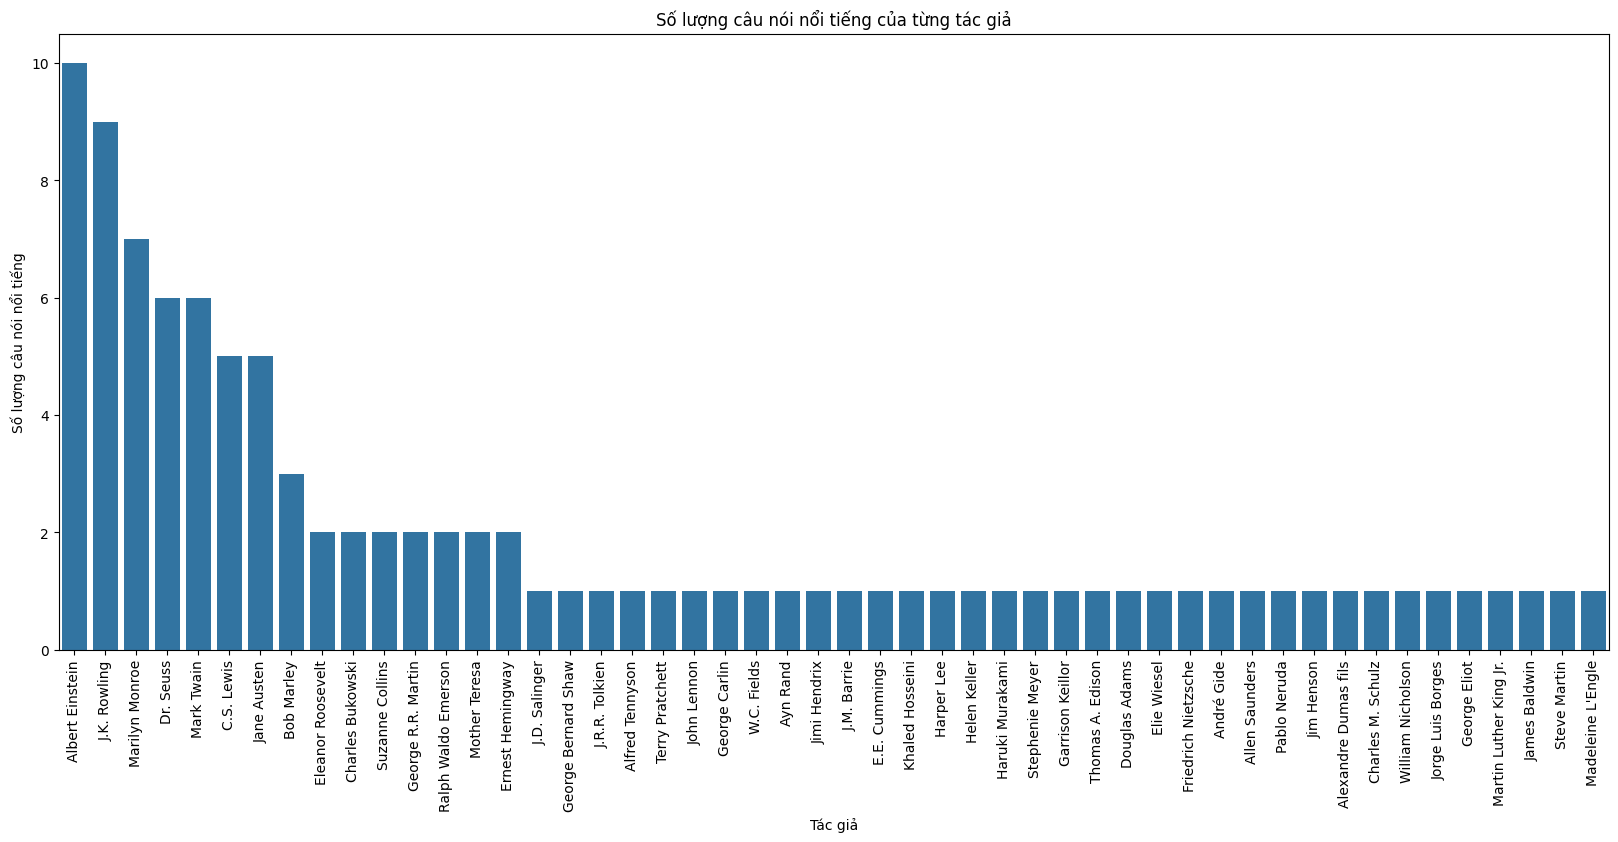

In [107]:
# Tính số lượng câu nói của mỗi tác giả
author_counts = df['Tacgia'].value_counts()

# Tạo DataFrame mới lưu trữ số lượng câu nói của từng tác giả
author_quotes_df = pd.DataFrame({'Tacgia': author_counts.index, 'Quote_count': author_counts.values})

# Trực quan hóa số lượng câu nói của từng tác giả bằng đồ thị cột
plt.figure(figsize=(20,8))
sns.barplot(x='Tacgia', y='Quote_count', data=author_quotes_df)
plt.xticks(rotation=90)
plt.title('Số lượng câu nói nổi tiếng của từng tác giả')
plt.xlabel('Tác giả')
plt.ylabel('Số lượng câu nói nổi tiếng')
plt.show()

### 3.2.3. Trích xuất đặc trưng- Feature Extraction

In [108]:
# Đặc trưng
Xfeatures = df['Quote']
# Nhãn
ylabels = df['Tacgia']

### 3.2.4. Suy luận

#### Dự đoán tên người nổi tiếng theo câu nói

In [109]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Vector hóa dữ liệu
cv = CountVectorizer()
X = cv.fit_transform(Xfeatures)

# Chia dữ liệu thành tập train và test
x_train,x_test,y_train,y_test = train_test_split(X,ylabels,test_size=0.33,random_state=42)

In [110]:
x_train.shape

(67, 663)

### Tính độ chính xác accuracy

In [111]:
from sklearn.naive_bayes import MultinomialNB

# Huấn luyện mô hình phân loại Multinomial Naive Bayes
clf = MultinomialNB()
clf.fit(x_train,y_train)
print("Độ chính xác của mô hình Multinomial Naive Bayes :",clf.score(x_test,y_test))

Độ chính xác của mô hình Multinomial Naive Bayes : 0.15151515151515152


In [112]:
from sklearn.linear_model import LogisticRegression

# Huấn luyện mô hình Logistic Regression
logit = LogisticRegression()
logit.fit(x_train,y_train)
print("Độ chính xác của mô hình Logistic Regression :",logit.score(x_test,y_test))

Độ chính xác của mô hình Logistic Regression : 0.15151515151515152


In [113]:
from sklearn.svm import SVC

# Huấn luyện mô hình Support Vector Machine
svc = SVC()
svc.fit(x_train,y_train)
print("Độ chính xác của mô hình Support Vector Machine :",svc.score(x_test,y_test))

Độ chính xác của mô hình Support Vector Machine : 0.09090909090909091


In [114]:
# Dự đoán tác giả của 3 câu nói bất kỳ
sample_verse1 = ["You can never get a cup of tea large enough or a book long enough to suit me."]
sample_verse2 = ["Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring."]
sample_verse3 = ["I have not failed. I've just found 10,000 ways that won't work."]

# Vector hóa câu nói
vect = cv.transform(sample_verse1).toarray()
vect2 = cv.transform(sample_verse2).toarray()
vect3 = cv.transform(sample_verse3).toarray()

In [115]:
# Dự đoán tác giả của câu nói bằng mô hình Multinomial Naive Bayes
predict = clf.predict(vect)
predict2 = clf.predict(vect2)
predict3 = clf.predict(vect3)
print("-----------------Dự đoán tác giả bằng mô hình Multinomial Naive Bayes---------------")
print("Tác giả của câu nói 1 là:",predict) # Đúng
print("Tác giả của câu nói 2 là:",predict2) # Sai
print("Tác giả của câu nói 3 là:",predict3) # Đúng

# Dự đoán tác giả của câu nói bằng mô hình Logistic Regression
lpredict = logit.predict(vect)
lpredict2 = logit.predict(vect2)
lpredict3 = logit.predict(vect3)
print("\n------------Dự đoán tác giả của câu nói bằng mô hình Logistic Regression------------")
print("Tác giả của câu nói 1 là:",lpredict) # Đúng
print("Tác giả của câu nói 2 là:",lpredict2) # Sai
print("Tác giả của câu nói 3 là:",lpredict3) # Đúng

# Dự đoán tác giả của câu nói bằng mô hình Support Vector Machine
svcpredict = svc.predict(vect)
svcpredict2 = svc.predict(vect2)
svcpredict3 = svc.predict(vect3)
print("\n------------Dự đoán tác giả của câu nói bằng mô hình Support Vector Machine------------")
print("Tác giả của câu nói 1 là:",svcpredict) # Sai
print("Tác giả của câu nói 2 là:",svcpredict2) # Đúng
print("Tác giả của câu nói 3 là:",svcpredict3) # Sai

-----------------Dự đoán tác giả bằng mô hình Multinomial Naive Bayes---------------
Tác giả của câu nói 1 là: ['C.S. Lewis']
Tác giả của câu nói 2 là: ['J.K. Rowling']
Tác giả của câu nói 3 là: ['Thomas A. Edison']

------------Dự đoán tác giả của câu nói bằng mô hình Logistic Regression------------
Tác giả của câu nói 1 là: ['C.S. Lewis']
Tác giả của câu nói 2 là: ['J.K. Rowling']
Tác giả của câu nói 3 là: ['Thomas A. Edison']

------------Dự đoán tác giả của câu nói bằng mô hình Support Vector Machine------------
Tác giả của câu nói 1 là: ['J.K. Rowling']
Tác giả của câu nói 2 là: ['J.K. Rowling']
Tác giả của câu nói 3 là: ['J.K. Rowling']


#### Độ tương đồng phong cách nói giữa các tác giả và tìm ra các tác giả có phong cách nói tương đồng nhau nhất

In [116]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import itertools

# Tạo và khởi tạo TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Chuyển đổi văn bản thành vector đặc trưng
X = tfidf_vectorizer.fit_transform(df['Quote'])

authors = df['Tacgia'].unique()
similarities = []

# Tính độ tương đồng phong cách nói giữa các tác giả
for author1, author2 in itertools.combinations(authors, 2):
    quotes_author1 = df[df['Tacgia'] == author1]['Quote']
    quotes_author2 = df[df['Tacgia'] == author2]['Quote']

    vector1 = X[df['Tacgia'] == author1]
    vector2 = X[df['Tacgia'] == author2]

    similarity = cosine_similarity(vector1, vector2)[0][0]
    similarities.append((author1, author2, similarity))

# Sắp xếp các độ tương đồng theo thứ tự giảm dần
similarities.sort(key=lambda x: x[2], reverse=True)

# In kết quả
for author1, author2, similarity in similarities:
    print(f"{author1} và {author2} có độ tương đồng phong cách nói là {similarity}")

Ayn Rand và Jimi Hendrix có độ tương đồng phong cách nói là 0.32783596038355256
Albert Einstein và J.K. Rowling có độ tương đồng phong cách nói là 0.30040580928828703
André Gide và George Eliot có độ tương đồng phong cách nói là 0.28462094483211553
André Gide và Madeleine L'Engle có độ tương đồng phong cách nói là 0.2735291575794521
Martin Luther King Jr. và Haruki Murakami có độ tương đồng phong cách nói là 0.23546957952190722
Jimi Hendrix và J.M. Barrie có độ tương đồng phong cách nói là 0.2312249525841643
André Gide và Ralph Waldo Emerson có độ tương đồng phong cách nói là 0.2277599487690295
André Gide và Allen Saunders có độ tương đồng phong cách nói là 0.22260301399293592
George Eliot và Madeleine L'Engle có độ tương đồng phong cách nói là 0.21785947141186932
Marilyn Monroe và André Gide có độ tương đồng phong cách nói là 0.21533212998278906
Eleanor Roosevelt và Harper Lee có độ tương đồng phong cách nói là 0.21414433369286384
J.K. Rowling và André Gide có độ tương đồng phong cách